In [8]:
from IPython.display import display, HTML

display(HTML("""<style>.jp-RenderedHTMLCommon,.jp-RenderedHTMLCommon p,.jp-RenderedHTMLCommon li {    font-size: 40px !important;}
.rendered_html,.rendered_html p,.rendered_html li {    font-size: 18px !important;}</style>"""))

# Welcome to the CMCB: Vertex models of collective cell dynamics course 2026.

This Notebook will guide you through creating a vertex based model, which is one method used to understand behaviour of confluent meshes of cells, which joined together form a tissue.

During embryogenesis, cells demonstrate complex self organised patterns driven by cell-cell interactions. In this practical, we will explore how to construct vertex models, which contain information about how cell shape, adhesion and cortical tensions can be incorporated to mathematical models, and how these microscopic interactions can influence tissue-scale self organisation. 




# A brief introduction:


Hello! Welcome to the CMCB course practical from the Erzberger lab on Vertex models of collective cell dynamics. 

In this practical we will introduce you to vertex model based methods, used in modern theoretical biophysics to model multicellular layers. We will focus on how multicellular scale behaviour emerges in a system which can be modelled from cell level properties, using a elastic based vertex model of an epithelial sheet of cells as an example.

In the taught sections of this practical, we will describe how we might model a flat 2D surface of cells, and describe what biophysical considerations might go in to such a model at the cell level, and how this lets us build towards replication of tissue scale observed behaviours from lower scale properties of individual cell shapes and interactions. 

The exercises will follow a computational description of the same process, with exercises providing a step by step  computational approach towards building a energetic vertex based model. Energetic based descriptions occur throughout physics, and enable numerical explorations of tissue behaviour. For different parameters, we will explore how cell scale properties and interactions result in different regions of tissue scale behaviour, primarily the solid and fluid like states of confluent tissues. 

By the end of this course, you will have an understanding of energetic based approaches towards modelling biological systems, how such models at the cell scale can influence higher scale structures, and how biological interactions can influence choices of physical or mathematical models, and the role that interacting parameters can be driven through biological considerations of the structures.

This course is inspired by the papers ... 'Random Walks in Biology' by Howard C. Berg<a name="cite_ref-1"></a>[<sup>[1]</sup>](#cite_note-1), which we would recommend as a good introduction to random walks from the perspective of applications to biology.



## Aims for the practical:

*   To provide an introduction to the approaches used in biophysical modeling
*   To provide an introduction to random walks and diffusion theory, and some possible applications
*   To demonstrate some of the differences between microscopic and macroscopic models


# What Are Vertex Models, and how can they help us understand biological systems?

Vertex models are a class of models which represent a confluent layer(s) of cells as interacting polygons. They were originally inspired by other non-biological classes of soft matter -particularly soap bubbles [\[1\]](#cite-note-1) and foams [\[2\]](#cite-note-2). In these, and other fluid-like systems, shape and pattern evolutions over time are driven by competition between internal pressure and surface tension, which can result in a wide range of observed behaviours, depending on the relative strengths of these terms.

## Vertex models and Epithelial confluent surfaces
For this short course, we primarily consider how vertex models can be applied to epithelial layers.

Epithelial layers can be visualised through light microscopy images with stains which display the cell membranes, e.g. 
![ExampleOfAnEpithelialDrosophilaEmbryo](Figures/Experimental_Images/Epithelial_Drosophila_Example_2.png)
Image provided courtesy of Anne Rosfelter; Yu-Chiun Wang, RIKEN Center for Biosystems Dynamics Research (BDR).

In a vertex model, the embryo surface can be treated as a confluent mesh whose dynamics are captured by the behaviours of the mesh which represents the cell shapes. For this image, a mesh based representation of the current state using a skeletonisation algorithm could look like:

![ExampleOfAnEpithelialDrosophilaMesh](Figures/Experimental_Images/Epithelial_Drosophila_Example_3_meshVers.png)

A fundamental assumption in vertex modelling is that a significant amount of multicellular behaviours can be captured by only directly modelling the positions of the vertices, shown as red dots here, rather than the entire cell body:
![ExampleOfAnEpithelialDrosophilaMeshWithV](Figures/Experimental_Images/Epithelial_Drosophila_Example_mesh_with_vertices.png)

# Preliminaries: install python package requirements. 

## This course requires only: a default python3 installation, matplotlib and numpy. Everything else is included in the project files.

These can be installed with the following instructions : Add instructions to a accompanying text file 

In [9]:

#import os
#print(os.getcwd())
#import source_py_files.mesh as mesh
#print(mesh.__file__)

# Setting up the geometry of an epithelial layer in a vertex model

# Exercise 1: From cells to polygons: Generating a mesh

For this course, classes, functions and methods are provided in other .py files to create your simulations. You may want to add or modify your own methods as we go.

As we saw above, in an image of a epithelial monolayer, we can identify cells their boundaries (edges), neighbours and positions just from the positions of vertices which when joined by straight edges, form polygonal "cells".

Let's begin with creating a hexagonal mesh. The Tissue we will simulate is defined in the class within source_pyfiles/tissue.py. The helpfully named tissue class within defines the tissue as a list of vertices, and connected edges. We can then generate a mesh of regular hexagons using the functions in source_pyfiles/mesh.py

The mesh depends on the size of the hexagon (a) and the number of hexagons which are tiled along the two directions. Depending on the simulation, we may want the boundaries to be periodic, which is an argument that can be passed to the mesh generation function.

Familiarise yourself with the mesh generation code. What happens if we have an odd number of cells in one direction? Adjust the code in mesh.generate_hexagonal_sheet to enforce that we have an even number of cells if the top/bottom or sides are periodic.

Check using the plotting functions provided in plotting.py that edges are shared and that vertices at the boundaries are tracked appropriately.

Later on, we will want to track properties of the cells, including quantifications of the shape. Use the function area_bargraph and perimeter in plotting to plot a distrbiution of the cell areas

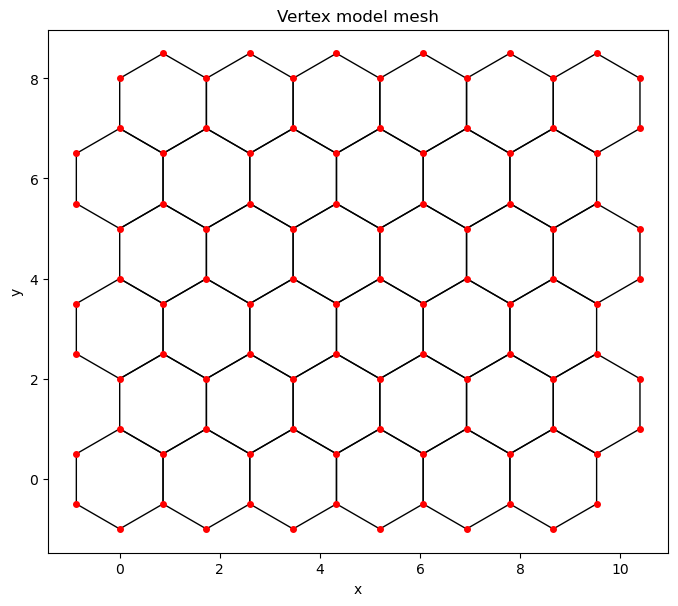

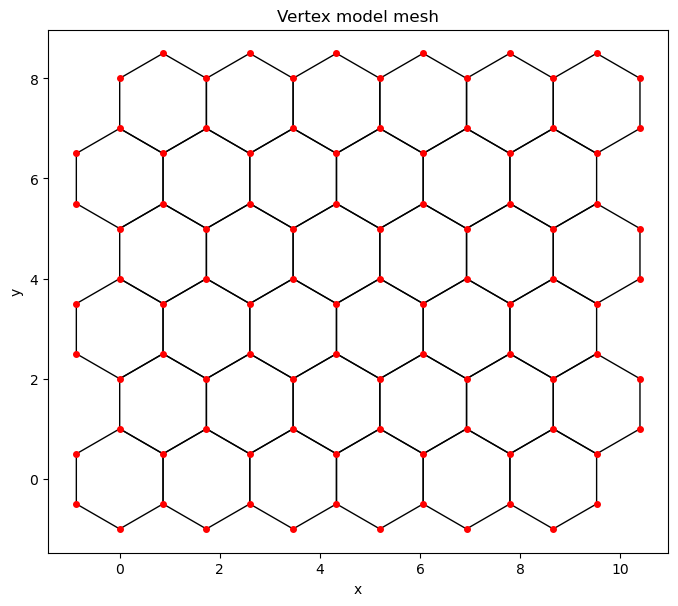

Plotting mesh 4


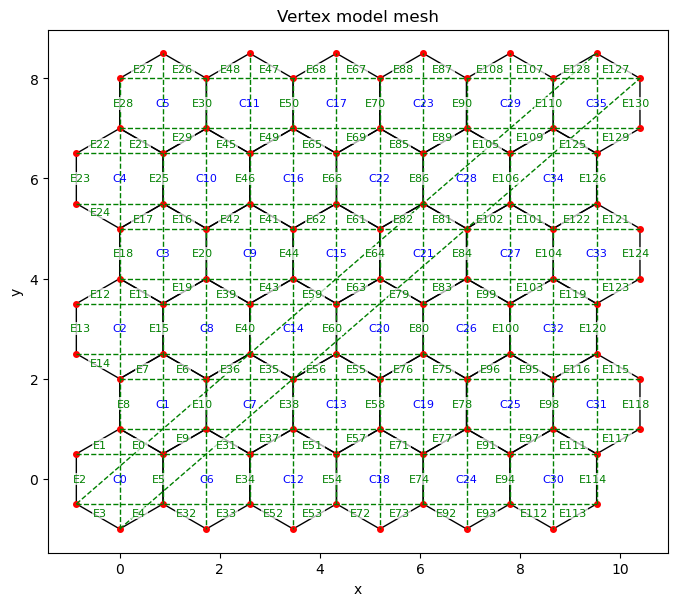

In [10]:
from source_py_files.tissue import Tissue 
from source_py_files import mesh
from source_py_files import plotting


Nx = 6
Ny = 6
a = 1

tissue = Tissue()
tissue2 = Tissue()
tissue3 = Tissue()
tissue4 = Tissue()

#print("Generating mesh 1")
mesh.generate_hexagonal_sheet(tissue,Nx,Ny,a,top_bottom_boundary_periodicity=False,side_boundary_periodicity=False)
#print("Plotting mesh 1")

plotting.plot_mesh(tissue)
plotting.plot_mesh(tissue,show_cell_ids=False,show_vertex_ids=False,show_periodic=True,show_edge_ids=False)

#mesh.generate_hexagonal_sheet(tissue2,Nx,Ny,a,top_bottom_boundary_periodicity=True,side_boundary_periodicity=False)
#print("Plotting mesh 2")
#plotting.plot_mesh(tissue2,show_cell_ids=True,show_vertex_ids=True,show_periodic=True,show_edge_ids=True)

#mesh.generate_hexagonal_sheet(tissue3,Nx,Ny,a,top_bottom_boundary_periodicity=False,side_boundary_periodicity=True)
#print("Plotting mesh 3")
#plotting.plot_mesh(tissue3,show_cell_ids=True,show_vertex_ids=True,show_periodic=True,show_edge_ids=True)

mesh.generate_hexagonal_sheet(tissue4,Nx,Ny,a,top_bottom_boundary_periodicity=True,side_boundary_periodicity=True)
print("Plotting mesh 4")
plotting.plot_mesh(tissue4,show_cell_ids=True,show_vertex_ids=False,show_periodic=True,show_edge_ids=True)







In [11]:
for edge in tissue4.edges:
    if edge.cells:
        print(f"Edge {edge.id} " f"({edge.v1.id}, {edge.v2.id}) "f"joins cells: "f"{[p.id for p in edge.cells]}")
print("Done")


for edge in tissue4.edges:
    if edge.periodic_partners:
        print(f"Edge {edge.id} " f"({edge.v1.id}, {edge.v2.id}) "f"has periodic partners: "f"{[p.id for p in edge.periodic_partners]}")
print("Done")

for vertex in tissue4.vertices:
    if vertex.periodic_partners:
        print(f"Vertex {vertex.id} "f"has periodic partners: "f"{[p.id for p in vertex.periodic_partners]}")

print("Done")

Edge 0 (0, 1) joins cells: [0, 1]
Edge 1 (1, 2) joins cells: [0, 31]
Edge 2 (2, 3) joins cells: [0, 30]
Edge 3 (3, 4) joins cells: [0, 35]
Edge 4 (4, 5) joins cells: [0, 5]
Edge 5 (5, 0) joins cells: [0, 6]
Edge 6 (6, 7) joins cells: [1, 8]
Edge 7 (7, 8) joins cells: [1, 2]
Edge 8 (8, 1) joins cells: [1, 31]
Edge 9 (0, 9) joins cells: [1, 6]
Edge 10 (9, 6) joins cells: [1, 7]
Edge 11 (10, 11) joins cells: [2, 3]
Edge 12 (11, 12) joins cells: [2, 33]
Edge 13 (12, 13) joins cells: [2, 32]
Edge 14 (13, 8) joins cells: [2, 31]
Edge 15 (7, 10) joins cells: [2, 8]
Edge 16 (14, 15) joins cells: [3, 10]
Edge 17 (15, 16) joins cells: [3, 4]
Edge 18 (16, 11) joins cells: [3, 33]
Edge 19 (10, 17) joins cells: [3, 8]
Edge 20 (17, 14) joins cells: [3, 9]
Edge 21 (18, 19) joins cells: [4, 5]
Edge 22 (19, 20) joins cells: [4, 35]
Edge 23 (20, 21) joins cells: [4, 34]
Edge 24 (21, 16) joins cells: [4, 33]
Edge 25 (15, 18) joins cells: [4, 10]
Edge 26 (22, 23) joins cells: [5, 6]
Edge 27 (23, 24) joins

# Why do physicists like minimisation of energies so much?
## How does a physical system evolve? 

In physics, systems that aren't under external forces, or otherwise actively consuming energy to prevent such changes, will move to minimise the energy of the system. This can be seen in systems all across nature, whether it is a ball in a gravitational field, who will roll down a hill to minimise gravitational potential energy, (increasing kinetic energy as it does, until at the minimum of the local gravitational potential, but lets not worry about that!)
![ExampleOfGravitationalEnergy](Figures/Drawings/example_ball_energy.png)

The change in gravitational potential energy is $U_{gravity} = mg \Delta h$
Another perhaps more relevant example is when an elastic band or spring is stretched (or compressed in the case of a spring), energy is stored within the spring, which then wants to return the spring to the original shape.

![ExampleOfElasticEnergy](Figures/Drawings/elastic-potential-energy.jpg) 
From : https://eschooltoday.com/learn/elastic-potential-energy/

would have energies proportional to how far the spring has stretched or compressed in the form 

\begin{align}
E_{\text{spring}} = \frac{1}{2} k \Delta x^2
\end{align}

Bubbles are capable of forming thin shells of fluid material which have shapes determined by surface tension. In the absence of other bubbles and external forces, this will result in a spherical bubble. If there are interactions between other bubbles, then the energy involves bubble-bubble contact depending on the surface area as

\begin{align}
E_{\text{bubble}} = \gamma_{bb} \sum_{i<j} l_{ij} + \gamma_{bf}\sum _{i} l_{i}
\end{align}
where $\gamma$ is a strength of surface tension, or adherence between surfaces. In the case of $\gamma_{bb}$ this represents the adherence based interaction between bubbles i and j, and $\gamma_{bf}$ represents the effect of surface tension over the area of the cell in contact with the surrounding environment.


# Exercise 2: What are the energies involved in a biologically motivated vertex model?  

Our starting mesh now will look something like : 
![10By10MeshPlot](Figures/Mesh_plots/Example_plot_10by10_mesh) 

What physical properties does each cell have, and how might they contribute to the energies of our system? As mentioned earlier, vertex models were inspired from soap bubbles and foams, we can take inspiration from these, as well as elastic spring like interactions.

We might be 

# Exercise 3: Exploring the energy landscape

# Exercise 4: What controls the evolution of cell shape? Deriving forces acting on cells from energy perturbations.

Given the expression for energy we now have above, containing Area elasticity, Perimeter elasticity and interface tensions,

\begin{align}
E=\frac{1}{2} k_A (A-A_0)^2 + \frac{1}{2} k_p \left(P-P_0\right)^2 + \frac{1}{2} \sum_{<ij>} \Lambda_{ij} l_{ij}
\end{align}
    
We can determine the force acting on a given vertex in the 2D plane of our epithelial layer by looking at how changing the position of the vertex affects the energy. Specifically, in the overdamped limit, the force on a vertex is given by the derivative of the vertex position:
    
\begin{align}
{\bf F_i} = -\frac{\partial E}{\partial {\bf r}_{i}}
\end{align}
    
Where $ {\bf r}_{i}$ is the position of the vertex i.
    
The derivative of the energy can actually be derived analytically here, but we'll avoid doing that and instead talk about what this means numerically.    
    
## A short introduction to partial derivatives
For those who are already confident with these methods, you can skip this section or relax for a few minutes!

Derivatives measure how something changes in space. For instance, if we know the distance above sea level of the bus coming to EMBL depends on how far you are from Alois-Link Platz, we could write this as $z=z(x)$, where x is the distance from the Alois-Link Platz bus stop to the EMBL bus stop. Of course, this goes up and down so the actual curve might look like : 

    (*Make image of a graph for derivative?*)
As you move a little distance $\delta$ along the bus route between Alois-Link Platz and EMBL, your height above sea level, z changes a bit. The derivative measures how much the height changes over the bus route. 
    
For a small enough $\delta$ this is approximately linear and we can write the change in height ratio to delta as:
\begin{align}
\text{relative height change} = \frac{z(x+\delta)-z(x)}{\delta}
\end{align}
    
But what is a good size for $\delta$? If the curve was very wiggly, perhaps our initial choice was too big. In that case we can make $\delta$ smaller. We could also keep doing this and take $\delta$ to be ***infinitesimally small***. This is called taking a limit of $\delta$ tending to zero, and is written like this:
    
\begin{align}
\frac{dz}{dx} = \lim_{\delta->0}\frac{z(x+\delta)-z(x)}{\delta}
\end{align}

This is the definition of an ordinary derivative! ***The ordinary derivative gives the slope of a function at the position $x$***.
    
However, the bus trip is actually a curve with lots of ups and downs and it might make more sense to write the position in the xy coordinates you would see on a map projection e.g.: 

\begin{align}
\text{slope} = \frac{z(x_2,y_2)-z(x_1,y_1)}{\delta}
\end{align}

Mathematically, we often only want to know how the function changes with respect to one variable.  If I only want to measure the change in x (latitude) at different points, I might want to keep y constant, which is where the partial derivative comes in.
    
\begin{align}
\text{slope along x} = \frac{z(x+\delta,y)-z(x,y)}{\delta}
\end{align}
Taking the limit of small movements, as before, ($\delta -> 0$) we get the partial derivative definition
\begin{align}
\frac{\partial z}{\partial x} = \lim_{\delta->0}\frac{z(x+\delta,y)-z(x,y)}{\delta}
\end{align}
This is the definition of a partial derivative! Here we use the symbols $\partial$ to indicate that we keep all other variables fixed when we change $x$.

# How can we incorporate 
        
\begin{align}
{\bf F_i} = -\frac{\partial E}{\partial {\bf r}_{i}}
\end{align}
    
in our numerical scheme to understand how the positions should change? ${\bf r}_{i}=(x_i,y_i)$ is the position of a given vertex. 
    
Moving a vertex changes the area, perimeter and edge lengths of a cell and the neighbours which that vertex is a part of. When we move a vertex we then have to calculate how the area A, perimeter P and affected edge lengths L: all change as a result. The way the energy changes can then be split in to different components which we add together (chain rule of derivatives):
    
\begin{align}
\frac{\partial E}{\partial x}&=\frac{\partial E}{\partial A}\frac{\partial A}{\partial x} + \frac{\partial E}{\partial P}\frac{\partial P}{\partial x}+ \frac{\partial E}{\partial L} \frac{\partial L}{\partial x}\\
\frac{\partial E}{\partial y}&=\frac{\partial E}{\partial A}\frac{\partial A}{\partial y} + \frac{\partial E}{\partial P}\frac{\partial P}{\partial y}+ \frac{\partial E}{\partial L} \frac{\partial L}{\partial y}
\end{align}

# Exercise 7: What are toplogical transitions? 

# Exercise N: Derivation of elastic moduli 

# Exercise N: Emergent properties : Is a tissue more like a solid, or more like a fluid?

In [5]:
from source_py_files import energy
from source_py_files import geometry
#print( energy.elasticity_energy(tissue,ka=1))
print(energy.energy_elasticity(tissue,ka=1.0),
     energy.energy_elasticity(tissue2,ka=1.0),
     energy.energy_elasticity(tissue3,ka=1.0),
     energy.energy_elasticity(tissue4,ka=1.0))
print(energy.energy_adhesion(tissue,Lambda=1.0))
print(energy.energy_contraction(tissue,gamma=1.0))

121.50000000000001 0.0 0.0 121.50000000000001
131.0
648.0


In [6]:
#for cell in tissue.cells:
#    print(cell.id, cell.area())
    
for edge in tissue.edges:
    print(edge.id)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130


In [7]:
#Check all cell areas and perimeters are equal
for cell in tissue.cells:
    print(f"{cell.perimeter():.6f}")

6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000
6.000000


# References
<a name = "cite-note-1">[1]</a> Marder, M. (1987) Soap-bubble growth}, Physical Review A.

<a name = "cite-note-2">[2]</a> Tohru Okuzono and Kyozi Kawasaki. (1995) Intermittent flow behavior of random foams: A computer experiment on foam rheology. Physical Review E



\begin{align}
C_{\text{guess}}(x,t) = \frac{C_0}{(2 \pi \sigma(t)^2)^\frac{1}{2}} e^{-\frac{1}{2}(\frac{x-\mu(t)}{\sigma(t)})^2}
\end{align}